# CSCI E-89: Homework 4

Paul Schwartzberg

## Problem 1: recognise handwritten digits

Adapted from the course notebook `1_pytorch_basic_cnn_digits.ipynb`. We replace scikit-learn's 8 x 8 digit images with MNIST images from torchvision. Each MNIST image has 28 x 28 pixels.

**Progress:** load and inspect the data. Training, evaluation and inference on my own handwriting will follow.

### 1. Set up the environment

Use the `cscie89` kernel. The printed Python path lets us check that the notebook uses the intended environment. A convolutional neural network (CNN) learns image features through filters whose weights change during training.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import datasets, transforms

# Fixed seeds make later splits and model initialisation more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python executable: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"Device: {device}")

Python executable: C:\Users\schwa\.conda\envs\cscie89\python.exe
PyTorch: 2.14.0+cpu
torchvision: 0.29.0+cpu
Device: cpu


### 2. Load MNIST through torchvision

A `Dataset` provides an image and its label when we request an item. `datasets.MNIST` supplies the images; `ToTensor()` converts them to the format PyTorch needs.

MNIST has 60,000 training images and 10,000 test images. <br>
We will later divide the training pool into training and validation sets. <br> The test set stays separate until final evaluation.

The shape `(1, 28, 28)` means one colour channel, 28 rows and 28 columns. <br>
Labels are integers from 0 to 9. <br> The first run downloads the data; later runs reuse the local files.

In [2]:
# ToTensor converts each greyscale image to a float tensor of shape
# (1, 28, 28) and scales its pixel values from 0-255 to 0-1.
transform = transforms.ToTensor()
DATA_DIR = Path("data")

mnist_train_full = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Inspect a training example; keep the test set for final evaluation.
image, label = mnist_train_full[0]
print(f"Training pool: {len(mnist_train_full):,} images")
print(f"Test set: {len(mnist_test):,} images")
print(f"One image: {tuple(image.shape)}")
print(f"Tensor type: {image.dtype}")
print(f"Pixel range in this image: {image.min().item():.1f} to {image.max().item():.1f}")
print(f"Label: {label}")

Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


...

MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


### 3. Inspect the images

Show one training example per class to check the labels and appearance.<br>
The digits are bright against a dark background. <br>When we prepare my handwritten digits later, we will match this format.

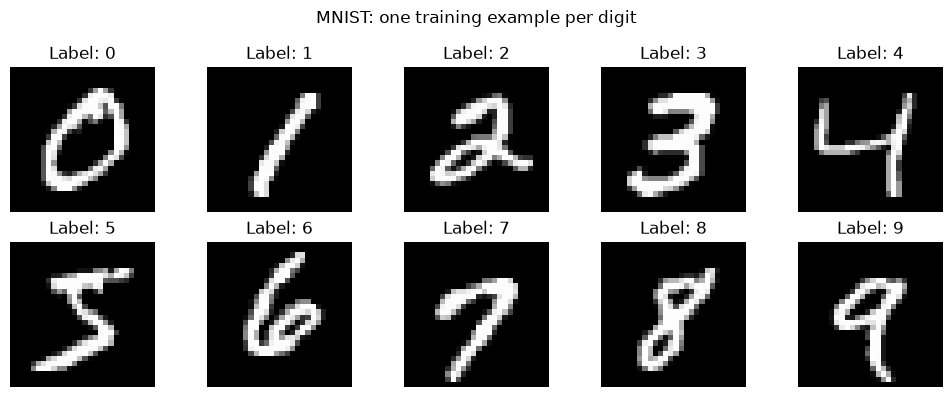

In [3]:
# Show one training image for each digit.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = (mnist_train_full.targets == digit).nonzero(as_tuple=True)[0][0].item()
    image, label = mnist_train_full[index]
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
fig.suptitle("MNIST: one training example per digit")
plt.tight_layout()
plt.show()

### Next step

Split the training pool into training and validation sets, then use `DataLoader` objects to serve batches of images to the model.

## Problem 2: improve flower classification

Adapted from `2_pytorch_CNN_Classify_flowers.ipynb`.

The task is to classify photos as daisy, dandelion, roses, sunflowers or tulips. <br>
The course model has three convolutional blocks and two linear layers. <br>We must add two convolutional blocks and one linear layer with ReLU, then document a small set of experiments.<br> We will use no data augmentation.

The supplied notebook records 75.1% training accuracy at its final epoch and 65.34% test accuracy for the checkpoint selected by validation loss. <br>These are different measures; the supplied results are reference results, not results from our own run.

We will keep the same data split across experiments, use validation results to choose settings and check for overfitting, <br>and reserve the test set for final evaluation. Adding depth does not guarantee better accuracy.

**Progress:** the data split, baseline and first deeper-model experiment are complete. <br>Further controlled experiments and final test evaluation remain.

### 2.1 Load the flower photos

Unlike MNIST, these photos arrive in folders, one per flower class. <br>`ImageFolder` reads the folder names and assigns integer labels in alphabetical order.

`Resize` makes every image 64 x 64 pixels; this can change its proportions. <br>`ToTensor` converts it to a tensor and scales the pixel values to 0-1.<br> `Compose` applies these operations in order. RGB photos have three channels, so each tensor has shape `(3, 64, 64)`.

The first run downloads an archive of about 220 MB into `data/`.<br> Git ignores this folder. We will split this catalogue into training, validation and test sets in the next step.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive

# Separate names keep the flower data distinct from Problem 1's MNIST data.
FLOWER_DATA_DIR = Path("data")
FLOWER_IMAGE_SIZE = 64
flower_root = FLOWER_DATA_DIR / "flower_photos"

# Reuse the downloaded photos on later runs.
if not flower_root.exists():
    download_and_extract_archive(
        "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
        download_root=str(FLOWER_DATA_DIR),
        md5="6f87fb78e9cc9ab41eff2015b380011d",
    )

# Resize to a common size and convert to tensors. No data augmentation.
flower_transform = transforms.Compose([
    transforms.Resize((FLOWER_IMAGE_SIZE, FLOWER_IMAGE_SIZE)),
    transforms.ToTensor(),
])
flower_catalog = datasets.ImageFolder(flower_root, transform=flower_transform)
flower_class_names = flower_catalog.classes
print(f"Images: {len(flower_catalog):,}")
print(f"Folder-to-label mapping: {flower_catalog.class_to_idx}")
flower_image, flower_label = flower_catalog[0]
print(f"One image: {tuple(flower_image.shape)}")
print(f"Label: {flower_label} ({flower_class_names[flower_label]})")

Images: 3,670
Folder-to-label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
One image: (3, 64, 64)
Label: 0 (daisy)


### 2.2 Inspect one photo per class

For MNIST, we removed the single channel dimension to plot a greyscale image. Here, all three colour channels are needed. `permute(1, 2, 0)` moves the channel dimension to the end, changing `(3, 64, 64)` into `(64, 64, 3)` for Matplotlib. It does not discard colour information.

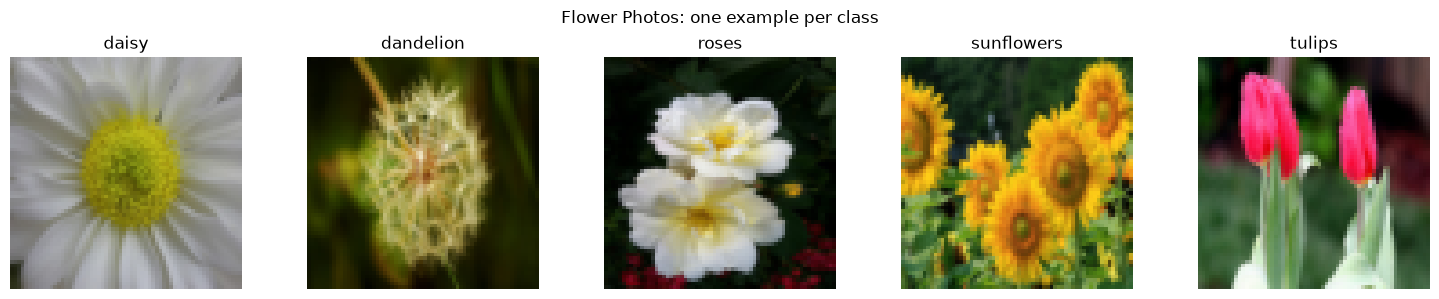

In [5]:
# Show one example per class to check the images and folder labels.
fig, axes = plt.subplots(1, len(flower_class_names), figsize=(15, 3))
for label, ax in enumerate(axes):
    index = flower_catalog.targets.index(label)
    image, target = flower_catalog[index]
    # RGB plotting needs (height, width, channels), rather than (channels, height, width).
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(flower_class_names[target])
    ax.axis("off")
fig.suptitle("Flower Photos: one example per class")
plt.tight_layout()
plt.show()

### 2.3 Split the data

We use 70% of the photos for training, about 15% for validation and about 15% for testing. Whole images cannot be split, so the last two sets differ by one image.

- **Training:** updates the model weights.
- **Validation:** compares experiments and selects the saved weights.
- **Test:** evaluates the final selected model.

`train_test_split` divides image indices. <br>`stratify` keeps approximately the same proportion of each flower class in each set.<br> A fixed `random_state` makes the split repeatable. <br>The second split uses the labels of the remaining images, in their current order.<br>

`Subset` refers to selected examples in the existing catalogue; it does not copy image files.<br> All three subsets therefore use the same resizing and tensor conversion. We will retain this split throughout our experiments.

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

FLOWER_SEED = 42
flower_indices = np.arange(len(flower_catalog))
flower_targets = np.asarray(flower_catalog.targets)

# Reserve 30% for validation and testing; use 70% for training.
flower_train_indices, flower_remaining_indices = train_test_split(
    flower_indices,
    test_size=0.30,
    random_state=FLOWER_SEED,
    stratify=flower_targets,
)

# Divide the reserved images equally between validation and testing.
flower_val_indices, flower_test_indices = train_test_split(
    flower_remaining_indices,
    test_size=0.50,
    random_state=FLOWER_SEED,
    stratify=flower_targets[flower_remaining_indices],
)

# Each Subset retrieves only its assigned images from the original catalogue.
flower_train_dataset = Subset(flower_catalog, flower_train_indices.tolist())
flower_val_dataset = Subset(flower_catalog, flower_val_indices.tolist())
flower_test_dataset = Subset(flower_catalog, flower_test_indices.tolist())

# Check that every image belongs to exactly one split.
flower_split_sets = [set(indices.tolist()) for indices in
                     (flower_train_indices, flower_val_indices, flower_test_indices)]
assert flower_split_sets[0].isdisjoint(flower_split_sets[1])
assert flower_split_sets[0].isdisjoint(flower_split_sets[2])
assert flower_split_sets[1].isdisjoint(flower_split_sets[2])
assert set.union(*flower_split_sets) == set(flower_indices.tolist())

for name, indices in [("Training", flower_train_indices),
                      ("Validation", flower_val_indices),
                      ("Test", flower_test_indices)]:
    counts = np.bincount(flower_targets[indices], minlength=len(flower_class_names))
    print(f"{name}: {len(indices):,} images")
    print(dict(zip(flower_class_names, counts.tolist())))

Training: 2,569 images
{'daisy': 443, 'dandelion': 629, 'roses': 449, 'sunflowers': 489, 'tulips': 559}
Validation: 550 images
{'daisy': 95, 'dandelion': 134, 'roses': 96, 'sunflowers': 105, 'tulips': 120}
Test: 551 images
{'daisy': 95, 'dandelion': 135, 'roses': 96, 'sunflowers': 105, 'tulips': 120}


### 2.4 Prepare batches

A `Dataset` supplies individual examples.<br> A `DataLoader` groups them into batches. <br>Here, a full batch contains 64 images and 64 labels. <br>Its image tensor has shape `(64, 3, 64, 64)`: batch size, colour channels, height and width.

We shuffle only the training set. <br>Validation and test examples keep a fixed order. <br>`num_workers=0` loads images in the current process, which keeps this setup straightforward. <br>The final batch may contain fewer than 64 images; the default keeps it.

The seeded generator controls training shuffles. <br>Its state advances as batches are requested.<br> When comparing models later, we will reset the model seed and training-loader generator for each run. <br>The preview below uses a separate loader.

In [7]:
FLOWER_BATCH_SIZE = 64

# Shuffle training examples into a new order on each pass through the data.
flower_train_loader = DataLoader(
    flower_train_dataset,
    batch_size=FLOWER_BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(FLOWER_SEED),
    num_workers=0,
)
flower_val_loader = DataLoader(
    flower_val_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)
flower_test_loader = DataLoader(
    flower_test_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)

# Use a separate loader for this preview so the training shuffle is untouched.
flower_preview_loader = DataLoader(
    flower_train_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)
flower_batch_images, flower_batch_labels = next(iter(flower_preview_loader))
print(f"Image batch: {tuple(flower_batch_images.shape)}")
print(f"Label batch: {tuple(flower_batch_labels.shape)}")
print(f"Label type: {flower_batch_labels.dtype}")
print(f"Training batches per epoch: {len(flower_train_loader)}")
assert flower_batch_images.shape == (FLOWER_BATCH_SIZE, 3, FLOWER_IMAGE_SIZE, FLOWER_IMAGE_SIZE)
assert flower_batch_labels.dtype == torch.int64

Image batch: (64, 3, 64, 64)
Label batch: (64,)
Label type: torch.int64
Training batches per epoch: 41


**Next step:** build and train the course model as a baseline. Then add the required layers and compare a small number of experiments using the same validation set.

### 2.5 Build the baseline CNN

A baseline is the starting model against which we compare changes. This is the three-block CNN from the course, with its original layer sizes.

Each block contains a convolution, ReLU and max pooling. A convolution learns filters that respond to image patterns. ReLU replaces negative values with zero. Max pooling keeps the largest value in each 2 x 2 region, halving the height and width. Padding keeps the convolution itself from shrinking the image.

For one image, the shapes after each block are:

`(3, 64, 64) -> (16, 32, 32) -> (32, 16, 16) -> (64, 8, 8)`

`Flatten` turns the last feature maps into 4,096 values per image. A linear layer combines them into 64 values, ReLU follows, and the final linear layer produces five class scores. These scores are called logits. The batch dimension remains throughout.

`CrossEntropyLoss` compares the raw scores with the correct class labels. We do not add softmax to the model because this loss handles the needed conversion internally. Adam uses gradients to update the weights.

Run this cell again before repeating baseline training: it creates fresh weights and a fresh optimiser. The fixed seed helps repeat runs within the same environment; it does not guarantee identical results across devices or software versions.

In [8]:
import copy
import json
import random
import time
from torch import nn

# Match the course baseline: 64 x 64 images, Adam, 0.001 learning rate, 15 epochs.
FLOWER_EPOCHS = 15
FLOWER_LEARNING_RATE = 0.001
flower_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(4)
random.seed(FLOWER_SEED)
np.random.seed(FLOWER_SEED)
torch.manual_seed(FLOWER_SEED)

class BaselineFlowerCNN(nn.Module):
    """The course model: three convolutional blocks and two linear layers."""

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (3, 64, 64) -> (16, 32, 32).
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: (16, 32, 32) -> (32, 16, 16).
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: (32, 16, 16) -> (64, 8, 8).
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (FLOWER_IMAGE_SIZE // 8) ** 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, images):
        features = self.features(images)
        return self.classifier(features)

flower_baseline = BaselineFlowerCNN(len(flower_class_names)).to(flower_device)
flower_criterion = nn.CrossEntropyLoss()
flower_optimizer = torch.optim.Adam(
    flower_baseline.parameters(), lr=FLOWER_LEARNING_RATE
)

print(f"Device: {flower_device}")
print(flower_baseline)
print(f"Trainable parameters: {sum(p.numel() for p in flower_baseline.parameters()):,}")
with torch.no_grad():
    flower_example_scores = flower_baseline(flower_batch_images.to(flower_device))
print(f"Output shape: {tuple(flower_example_scores.shape)}")
assert flower_example_scores.shape == (len(flower_batch_images), len(flower_class_names))

Device: cpu
BaselineFlowerCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 286,117
Output shape: (64, 5)


### 2.6 Train and validate the baseline

An epoch is one complete pass through the training set. We use 15 epochs and a learning rate of 0.001, matching the course baseline.

The evaluation function measures loss and accuracy without changing weights. `model.eval()` selects evaluation behaviour; `torch.no_grad()` avoids recording calculations for backpropagation.

For each training batch we clear old gradients, calculate scores, measure loss, calculate gradients and update weights. At the end of each epoch, we evaluate on validation images. Training metrics are accumulated while weights change; validation metrics use the weights at the end of the epoch.

We retain a separate copy of the weights whenever validation loss improves. After all 15 epochs, we restore the best copy. This is checkpoint selection, not early stopping: every epoch still runs. We do not use the test loader here.

In [9]:
def evaluate_flower_model(model, loader):
    """Measure average loss and accuracy without updating model weights."""
    model.eval()
    loss_sum = 0.0
    correct = 0
    count = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(flower_device)
            labels = labels.to(flower_device)
            scores = model(images)
            loss = flower_criterion(scores, labels)
            # Weight each batch by its size; the last batch can be smaller.
            loss_sum += loss.item() * len(labels)
            correct += (scores.argmax(dim=1) == labels).sum().item()
            count += len(labels)
    return loss_sum / count, correct / count

In [10]:
# Recreate the loader so earlier notebook activity does not change its shuffle.
flower_train_loader = DataLoader(
    flower_train_dataset, batch_size=FLOWER_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(FLOWER_SEED), num_workers=0,
)
flower_baseline_history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
}
flower_best_val_loss = float("inf")
flower_best_state = None
flower_best_epoch = 0
flower_start_time = time.perf_counter()

for epoch in range(1, FLOWER_EPOCHS + 1):
    flower_baseline.train()
    loss_sum = 0.0
    correct = 0
    count = 0
    for images, labels in flower_train_loader:
        images = images.to(flower_device)
        labels = labels.to(flower_device)
        flower_optimizer.zero_grad()                 # Clear previous gradients.
        scores = flower_baseline(images)             # Calculate class scores.
        loss = flower_criterion(scores, labels)       # Measure prediction error.
        loss.backward()                              # Calculate gradients.
        flower_optimizer.step()                      # Update model weights.
        loss_sum += loss.item() * len(labels)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        count += len(labels)

    train_loss = loss_sum / count
    train_accuracy = correct / count
    val_loss, val_accuracy = evaluate_flower_model(flower_baseline, flower_val_loader)
    flower_baseline_history["train_loss"].append(train_loss)
    flower_baseline_history["train_accuracy"].append(train_accuracy)
    flower_baseline_history["val_loss"].append(val_loss)
    flower_baseline_history["val_accuracy"].append(val_accuracy)

    if val_loss < flower_best_val_loss:
        flower_best_val_loss = val_loss
        flower_best_epoch = epoch
        # Copy the weights so later training does not change this saved state.
        flower_best_state = copy.deepcopy(flower_baseline.state_dict())

    print(f"Epoch {epoch:02d}/{FLOWER_EPOCHS} | "
          f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
          f"validation loss {val_loss:.3f}, accuracy {val_accuracy:.1%}", flush=True)

flower_training_seconds = time.perf_counter() - flower_start_time
flower_baseline.load_state_dict(flower_best_state)
flower_baseline.eval()
flower_selected_val_loss, flower_selected_val_accuracy = evaluate_flower_model(
    flower_baseline, flower_val_loader
)
assert abs(flower_selected_val_loss - flower_best_val_loss) < 1e-6
print(f"Restored epoch {flower_best_epoch}, chosen by lowest validation loss.")
print(f"Selected validation accuracy: {flower_selected_val_accuracy:.2%}")
print(f"Training time: {flower_training_seconds / 60:.1f} minutes")

Epoch 01/15 | train loss 1.453, accuracy 33.4% | validation loss 1.277, accuracy 45.6%
Epoch 02/15 | train loss 1.187, accuracy 48.7% | validation loss 1.119, accuracy 54.9%
Epoch 03/15 | train loss 1.088, accuracy 54.3% | validation loss 1.137, accuracy 52.5%
Epoch 04/15 | train loss 1.064, accuracy 56.2% | validation loss 1.022, accuracy 60.4%
Epoch 05/15 | train loss 0.975, accuracy 61.6% | validation loss 0.991, accuracy 60.0%
Epoch 06/15 | train loss 0.963, accuracy 62.2% | validation loss 0.994, accuracy 61.1%
Epoch 07/15 | train loss 0.907, accuracy 63.5% | validation loss 0.981, accuracy 59.5%
Epoch 08/15 | train loss 0.869, accuracy 65.6% | validation loss 1.029, accuracy 60.5%
Epoch 09/15 | train loss 0.838, accuracy 66.0% | validation loss 0.978, accuracy 59.3%
Epoch 10/15 | train loss 0.821, accuracy 67.1% | validation loss 0.941, accuracy 63.1%
Epoch 11/15 | train loss 0.780, accuracy 69.5% | validation loss 0.915, accuracy 64.2%
Epoch 12/15 | train loss 0.770, accuracy 69

Epoch 02/15 | train loss 1.187, accuracy 48.7% | validation loss 1.119, accuracy 54.9%


Epoch 03/15 | train loss 1.088, accuracy 54.3% | validation loss 1.137, accuracy 52.5%


Epoch 04/15 | train loss 1.064, accuracy 56.2% | validation loss 1.022, accuracy 60.4%


Epoch 05/15 | train loss 0.975, accuracy 61.6% | validation loss 0.991, accuracy 60.0%


...

Epoch 12/15 | train loss 0.770, accuracy 69.4% | validation loss 0.977, accuracy 61.6%


Epoch 13/15 | train loss 0.740, accuracy 70.0% | validation loss 0.934, accuracy 63.8%


Epoch 14/15 | train loss 0.707, accuracy 71.3% | validation loss 0.990, accuracy 63.1%


Epoch 15/15 | train loss 0.684, accuracy 73.6% | validation loss 1.038, accuracy 63.8%


Restored epoch 11, chosen by lowest validation loss.
Selected validation accuracy: 64.18%
Training time: 1.6 minutes


### 2.7 Inspect learning curves and save the baseline

Lower loss and higher accuracy indicate improvement. If training improves while validation loss rises, that suggests overfitting. The dashed line marks the epoch selected by validation loss, which need not have the highest validation accuracy.

We save the selected weights, validation results and data split. A reload check verifies that the saved weights reproduce the same scores on a training batch. Test results remain pending until we have compared the planned experiments.

The deeper model required by the assignment will be a separate experiment: five convolutional blocks and three linear layers, with ReLU after the additional hidden linear layer.

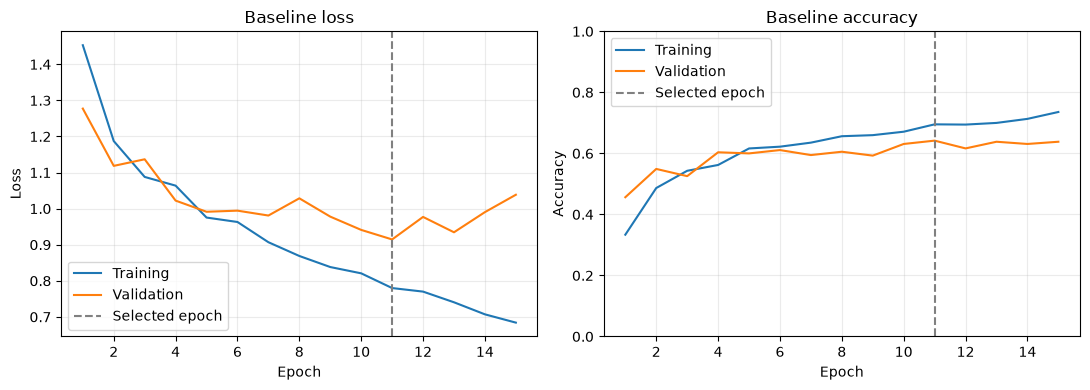

Saved baseline weights to outputs\flowers\baseline_cnn.pth; reload verified.
Saved validation results and the exact data split. Test evaluation remains pending.


In [14]:
flower_epochs = np.arange(1, FLOWER_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(flower_epochs, flower_baseline_history["train_" + metric], label="Training")
    ax.plot(flower_epochs, flower_baseline_history["val_" + metric], label="Validation")
    ax.axvline(flower_best_epoch, color="gray", linestyle="--", label="Selected epoch")
    ax.set(xlabel="Epoch", ylabel=metric.capitalize(), title="Baseline " + metric)
    ax.legend()
    ax.grid(alpha=0.25)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

flower_output_dir = Path("outputs") / "flowers"
flower_output_dir.mkdir(parents=True, exist_ok=True)
flower_baseline_path = flower_output_dir / "baseline_cnn.pth"
torch.save({
    "state_dict": {k: v.detach().cpu() for k, v in flower_baseline.state_dict().items()},
    "architecture": "BaselineFlowerCNN",
    "class_names": flower_class_names,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "best_epoch": flower_best_epoch,
}, flower_baseline_path)

# Check that saving and reloading preserves the model's scores.
flower_checkpoint = torch.load(flower_baseline_path, map_location=flower_device, weights_only=True)
flower_reloaded_baseline = BaselineFlowerCNN(len(flower_class_names)).to(flower_device)
flower_reloaded_baseline.load_state_dict(flower_checkpoint["state_dict"])
flower_reloaded_baseline.eval()
with torch.no_grad():
    flower_check_batch = flower_batch_images.to(flower_device)
    torch.testing.assert_close(
        flower_baseline(flower_check_batch), flower_reloaded_baseline(flower_check_batch)
    )

flower_baseline_metrics = {
    "experiment": "course_baseline",
    "architecture": "BaselineFlowerCNN",
    "epochs": FLOWER_EPOCHS,
    "learning_rate": FLOWER_LEARNING_RATE,
    "batch_size": FLOWER_BATCH_SIZE,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "device": str(flower_device),
    "pytorch_version": str(torch.__version__),
    "best_epoch": flower_best_epoch,
    "selected_validation_loss": flower_selected_val_loss,
    "selected_validation_accuracy": flower_selected_val_accuracy,
    "training_seconds": flower_training_seconds,
    "history": flower_baseline_history,
    "test_evaluated": False,
}
(flower_output_dir / "baseline_metrics.json").write_text(
    json.dumps(flower_baseline_metrics, indent=2), encoding="utf-8"
)
# Keep the exact split and class mapping for later experiments and visualisations.
flower_split_manifest = {
    "seed": FLOWER_SEED,
    "class_to_idx": flower_catalog.class_to_idx,
    "splits": {
        name: [Path(flower_catalog.samples[int(i)][0]).relative_to(flower_root).as_posix()
               for i in indices]
        for name, indices in [("train", flower_train_indices),
                              ("validation", flower_val_indices),
                              ("test", flower_test_indices)]
    },
}
(flower_output_dir / "split_manifest.json").write_text(
    json.dumps(flower_split_manifest, indent=2), encoding="utf-8"
)
print(f"Saved baseline weights to {flower_baseline_path}; reload verified.")
print("Saved validation results and the exact data split. Test evaluation remains pending.")

### Baseline findings

This run used the CPU and completed 15 epochs in about 2.1 minutes in the latest saved run. <br>The model has 286,117 trainable parameters.

| Measure | Result |
|---|---:|
| Epoch selected by lowest validation loss | 11 |
| Selected validation loss | 0.9146 |
| Selected validation accuracy | 64.18% |
| Final-epoch training accuracy | 73.57% |
| Final-epoch validation accuracy | 63.82% |

Training accuracy improved after epoch 11, but validation loss increased. <br>This suggests overfitting and supports retaining the earlier checkpoint. <br>A higher training score alone does not establish that a change helps on unseen images.

These are results from our run, not copied from the course notebook. <br>Differences from the course results can arise from the device, software versions and numerical calculations. <br>We will compare our later experiments with this baseline using the same split and evaluation method. The test set has not been evaluated.

**Next step:** add two convolutional blocks and one hidden linear layer with ReLU. <br>Keep the initial comparison small and record whether the deeper model improves validation performance; greater depth does not guarantee improvement.

### 2.8 Understand the baseline curves

At epoch 15, training loss is about 0.684 and validation loss about 1.038. Training accuracy is 73.57%, <br>while validation accuracy is 63.82% (351 of 550 validation images). <br>Accuracy counts correct top-scoring classes. <br>Cross-entropy loss also accounts for the score assigned to the correct class; confident errors incur a larger penalty. <br>Loss is not a percentage and can exceed one.

Validation loss reaches its minimum at epoch 11.<br> Later training lowers training loss but does not lower validation loss, suggesting overfitting. <br>We keep epoch 11's weights, whose validation accuracy is 64.18% (353 of 550 images). <br>Training accuracy is measured while weights change within an epoch; validation accuracy uses the fixed weights at its end.

Adding layers may help the model learn useful patterns, but it can also make training harder or increase overfitting.<br> We need an experiment to find out.

### 2.9 Build the required deeper model

A convolutional block here means `Conv2d -> ReLU -> MaxPool2d`. <br>Convolution learns weighted combinations of nearby values across the input channels. Each output channel is a feature map. <br>ReLU replaces negative values with zero.<br> Pooling reduces each feature map's height and width. Later blocks process the feature maps produced by earlier blocks.

We retain the first three blocks' structure and add two blocks. <br>This is a new model with fresh weights; it does not reuse the trained baseline weights.

| Stage | Baseline: shape per image | Deeper model: shape per image |
|---|---|---|
| Input | 3 x 64 x 64 | 3 x 64 x 64 |
| Block 1 | 16 x 32 x 32 | 16 x 32 x 32 |
| Block 2 | 32 x 16 x 16 | 32 x 16 x 16 |
| Block 3 | 64 x 8 x 8 | 64 x 8 x 8 |
| New block 4 | — | 128 x 4 x 4 |
| New block 5 | — | 256 x 2 x 2 |
| Flatten | 4,096 | 1,024 |
| Hidden linear layer + ReLU | 64 | 64 |
| New hidden linear layer + ReLU | — | 32 |
| Output linear layer | 5 | 5 |

A linear layer computes weighted sums of its inputs and adds learned biases.<br>The new `Linear(64, 32)` produces 32 values from 64 inputs. Its ReLU lets the classifier learn nonlinear relationships. <br>Two linear layers in succession without an intervening nonlinear activation are equivalent to a single affine transformation.

Five pooling stages reduce 64 x 64 to 2 x 2. <br>The first linear layer must therefore accept `256 * 2 * 2 = 1024` inputs, rather than the baseline's 4096. <br>The final layer still produces five raw scores; there is no ReLU or softmax after it. <br>We keep the 3 x 3 kernels, max pooling and ReLU for this first deeper-model comparison.

In [16]:
import torch
from torch import nn

class DeeperFlowerCNN(nn.Module):
    """Five convolutional blocks and three linear layers for 64 x 64 RGB images."""

    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: three colour channels -> 16 feature maps.
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                       # 64 x 64 -> 32 x 32
            # Block 2.
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                       # 32 x 32 -> 16 x 16
            # Block 3: the last block in the original model.
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                       # 16 x 16 -> 8 x 8
            # NEW block 4.
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                       # 8 x 8 -> 4 x 4
            # NEW block 5.
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                       # 4 x 4 -> 2 x 2
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                         # 256 * 2 * 2 = 1,024 values
            nn.Linear(256 * 2 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),                     # NEW hidden linear layer
            nn.ReLU(),                            # Required activation after it
            nn.Linear(32, num_classes),           # Five raw class scores
        )

    def forward(self, images):
        features = self.features(images)
        return self.classifier(features)


### 2.10 Check the deeper model before training

The following cell passes a batch through every stage and prints its shape. <br>It checks that we have exactly five convolutional layers, three linear layers and five finite output scores per image. <br>These are structural checks, not a test of classification accuracy. <br>The test dataset is not used.

The model definition also lives in `05_deeper_flower_model.py` for reuse. <br>The next step is to train this model with the same split, batch size, learning rate and epoch budget as the baseline, then compare validation results.

In [17]:
# Fresh weights: this model has not been trained yet.
torch.manual_seed(FLOWER_SEED)
flower_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flower_deeper = DeeperFlowerCNN(len(flower_class_names)).to(flower_device)

# Follow an actual training batch through the model, without changing weights.
flower_deeper.eval()
with torch.no_grad():
    values = flower_batch_images.to(flower_device)
    print(f"Input: {tuple(values.shape)}")
    for layer_number, layer in enumerate(flower_deeper.features, start=1):
        values = layer(values)
        if isinstance(layer, nn.MaxPool2d):
            print(f"After block {layer_number // 3}: {tuple(values.shape)}")
    for layer in flower_deeper.classifier:
        values = layer(values)
        print(f"After {type(layer).__name__}: {tuple(values.shape)}")
    torch.testing.assert_close(values, flower_deeper(flower_batch_images.to(flower_device)))

assert values.shape == (len(flower_batch_images), len(flower_class_names))
assert torch.isfinite(values).all()
assert sum(isinstance(layer, nn.Conv2d) for layer in flower_deeper.modules()) == 5
assert sum(isinstance(layer, nn.Linear) for layer in flower_deeper.modules()) == 3
print(f"Trainable parameters: {sum(p.numel() for p in flower_deeper.parameters()):,}")
print("Architecture checks passed. These weights are untrained; no accuracy result yet.")

Input: (64, 3, 64, 64)
After block 1: (64, 16, 32, 32)
After block 2: (64, 32, 16, 16)
After block 3: (64, 64, 8, 8)
After block 4: (64, 128, 4, 4)
After block 5: (64, 256, 2, 2)
After Flatten: (64, 1024)
After Linear: (64, 64)
After ReLU: (64, 64)
After Linear: (64, 32)
After ReLU: (64, 32)
After Linear: (64, 5)
Trainable parameters: 460,453
Architecture checks passed. These weights are untrained; no accuracy result yet.


### 2.11 Train the deeper model: first experiment

We now test whether the required deeper architecture helps under the baseline settings: 64 x 64 images, batches of 64, Adam with learning rate 0.001, and 15 epochs. We use the same image split and reset the seed and training-loader generator. No data augmentation is used.

Only the architecture changes. Its extra blocks also change the number and spatial size of the final feature maps, so this compares the complete architecture change rather than isolating depth alone. The new model starts with fresh weights; it does not continue training the baseline.

Run the setup cell below before repeating this training experiment. We reuse `evaluate_flower_model` from Section 2.6. The lowest validation loss selects the saved epoch. All 15 epochs run, and no test-set score is used to guide this experiment.

In [4]:
# Reset the experiment so rerunning this cell starts from fresh weights.
import copy
import json
import random
import time

FLOWER_EPOCHS = 15
FLOWER_LEARNING_RATE = 0.001
torch.set_num_threads(4)
random.seed(FLOWER_SEED)
np.random.seed(FLOWER_SEED)
torch.manual_seed(FLOWER_SEED)
flower_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flower_deeper = DeeperFlowerCNN(len(flower_class_names)).to(flower_device)
flower_criterion = nn.CrossEntropyLoss()
flower_deeper_optimizer = torch.optim.Adam(
    flower_deeper.parameters(), lr=FLOWER_LEARNING_RATE
)

# Check that the saved baseline used these same experiment settings and split.
flower_output_dir = Path("outputs") / "flowers"
flower_reference_metrics = json.loads((flower_output_dir / "baseline_metrics.json").read_text())
for key, value in [("epochs", FLOWER_EPOCHS), ("learning_rate", FLOWER_LEARNING_RATE),
                   ("batch_size", FLOWER_BATCH_SIZE), ("image_size", FLOWER_IMAGE_SIZE),
                   ("seed", FLOWER_SEED)]:
    assert flower_reference_metrics[key] == value, f"Baseline setting differs: {key}"
flower_saved_split = json.loads((flower_output_dir / "split_manifest.json").read_text())
assert flower_saved_split["class_to_idx"] == flower_catalog.class_to_idx
for name, indices in [("train", flower_train_indices),
                      ("validation", flower_val_indices), ("test", flower_test_indices)]:
    paths = [Path(flower_catalog.samples[int(i)][0]).relative_to(flower_root).as_posix()
             for i in indices]
    assert paths == flower_saved_split["splits"][name], f"Different split: {name}"
print("Baseline settings and exact image split verified. Starting a fresh deeper model.")

Baseline settings and exact image split verified. Starting a fresh deeper model.


In [5]:
# Recreate the loader so earlier notebook activity does not change its shuffle.
flower_train_loader = DataLoader(
    flower_train_dataset, batch_size=FLOWER_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(FLOWER_SEED), num_workers=0,
)
flower_deeper_history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
}
flower_deeper_best_val_loss = float("inf")
flower_deeper_best_state = None
flower_deeper_best_epoch = 0
flower_deeper_start_time = time.perf_counter()

for epoch in range(1, FLOWER_EPOCHS + 1):
    flower_deeper.train()
    loss_sum = 0.0
    correct = 0
    count = 0
    for images, labels in flower_train_loader:
        images = images.to(flower_device)
        labels = labels.to(flower_device)
        flower_deeper_optimizer.zero_grad()                 # Clear previous gradients.
        scores = flower_deeper(images)             # Calculate class scores.
        loss = flower_criterion(scores, labels)       # Measure prediction error.
        loss.backward()                              # Calculate gradients.
        flower_deeper_optimizer.step()                      # Update model weights.
        loss_sum += loss.item() * len(labels)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        count += len(labels)

    train_loss = loss_sum / count
    train_accuracy = correct / count
    val_loss, val_accuracy = evaluate_flower_model(flower_deeper, flower_val_loader)
    flower_deeper_history["train_loss"].append(train_loss)
    flower_deeper_history["train_accuracy"].append(train_accuracy)
    flower_deeper_history["val_loss"].append(val_loss)
    flower_deeper_history["val_accuracy"].append(val_accuracy)

    if val_loss < flower_deeper_best_val_loss:
        flower_deeper_best_val_loss = val_loss
        flower_deeper_best_epoch = epoch
        # Copy the weights so later training does not change this saved state.
        flower_deeper_best_state = copy.deepcopy(flower_deeper.state_dict())

    print(f"Epoch {epoch:02d}/{FLOWER_EPOCHS} | "
          f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
          f"validation loss {val_loss:.3f}, accuracy {val_accuracy:.1%}", flush=True)

flower_deeper_training_seconds = time.perf_counter() - flower_deeper_start_time
flower_deeper.load_state_dict(flower_deeper_best_state)
flower_deeper.eval()
flower_deeper_selected_val_loss, flower_deeper_selected_val_accuracy = evaluate_flower_model(
    flower_deeper, flower_val_loader
)
assert abs(flower_deeper_selected_val_loss - flower_deeper_best_val_loss) < 1e-6
print(f"Restored epoch {flower_deeper_best_epoch}, chosen by lowest validation loss.")
print(f"Selected validation accuracy: {flower_deeper_selected_val_accuracy:.2%}")
print(f"Training time: {flower_deeper_training_seconds / 60:.1f} minutes")

Epoch 01/15 | train loss 1.555, accuracy 23.9% | validation loss 1.468, accuracy 32.5%


Epoch 02/15 | train loss 1.358, accuracy 34.6% | validation loss 1.342, accuracy 39.6%


Epoch 03/15 | train loss 1.309, accuracy 41.5% | validation loss 1.327, accuracy 41.6%


Epoch 04/15 | train loss 1.249, accuracy 46.4% | validation loss 1.204, accuracy 48.2%


Epoch 05/15 | train loss 1.169, accuracy 49.0% | validation loss 1.207, accuracy 47.3%


...

Epoch 12/15 | train loss 0.828, accuracy 66.8% | validation loss 0.968, accuracy 62.5%


Epoch 13/15 | train loss 0.828, accuracy 68.6% | validation loss 0.906, accuracy 64.7%


Epoch 14/15 | train loss 0.772, accuracy 69.8% | validation loss 0.922, accuracy 65.6%


Epoch 15/15 | train loss 0.740, accuracy 71.0% | validation loss 0.923, accuracy 66.0%


Restored epoch 13, chosen by lowest validation loss.
Selected validation accuracy: 64.73%
Training time: 1.7 minutes


### 2.12 Compare the baseline and deeper model

Compare validation metrics from each model's selected checkpoint. An accuracy change is reported in percentage points: for example, moving from 60% to 65% is a gain of 5 percentage points.

We plot both training and validation histories to look for overfitting. A deeper model is not automatically better. This is one run per architecture with one fixed seed; a small difference should not be treated as proof of a general advantage. We save the deeper weights separately and check that reloading preserves its scores.

Deeper weights saved and reload verified.
Model         Epoch   Val loss   Val accuracy
Baseline         11     0.9146         64.18%
Deeper           13     0.9058         64.73%
Validation accuracy change: +0.55 percentage points


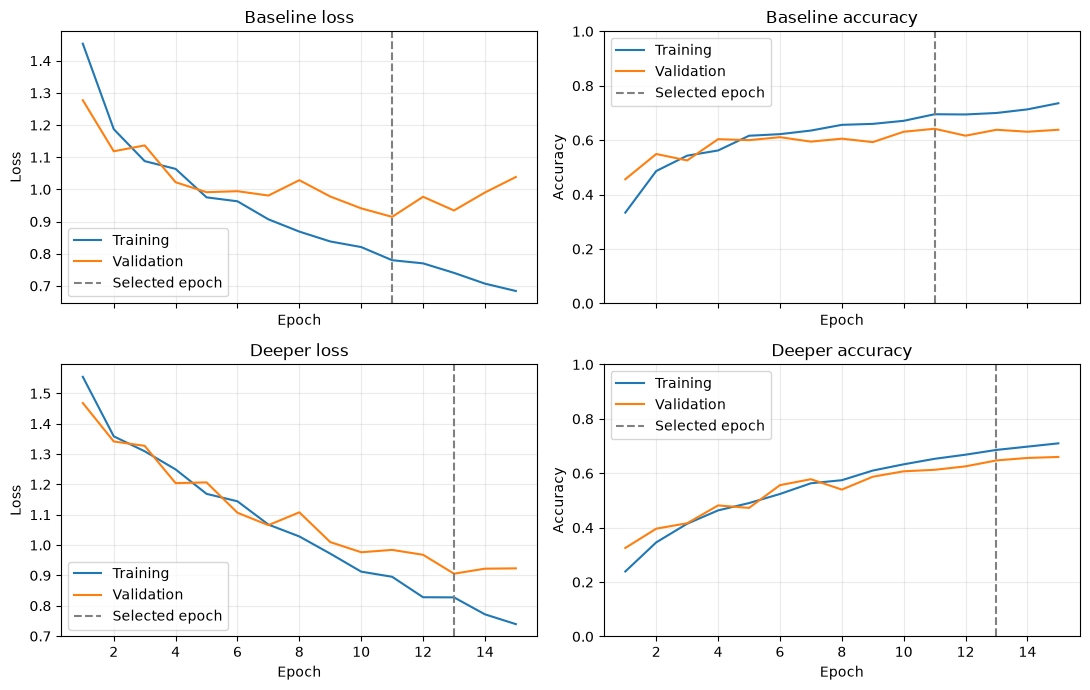

Test evaluation remains pending while we compare experiments.


In [6]:
# Save the selected deeper checkpoint separately from the baseline.
flower_deeper_path = flower_output_dir / "deeper_cnn.pth"
torch.save({
    "state_dict": {k: v.detach().cpu() for k, v in flower_deeper.state_dict().items()},
    "architecture": "DeeperFlowerCNN",
    "class_names": flower_class_names,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "best_epoch": flower_deeper_best_epoch,
}, flower_deeper_path)
flower_deeper_checkpoint = torch.load(flower_deeper_path, map_location=flower_device, weights_only=True)
flower_reloaded_deeper = DeeperFlowerCNN(len(flower_class_names)).to(flower_device)
flower_reloaded_deeper.load_state_dict(flower_deeper_checkpoint["state_dict"])
flower_reloaded_deeper.eval()
with torch.no_grad():
    check_images = flower_batch_images.to(flower_device)
    torch.testing.assert_close(flower_deeper(check_images), flower_reloaded_deeper(check_images))

flower_deeper_metrics = {
    "experiment": "deeper_same_settings",
    "architecture": "DeeperFlowerCNN",
    "epochs": FLOWER_EPOCHS,
    "learning_rate": FLOWER_LEARNING_RATE,
    "batch_size": FLOWER_BATCH_SIZE,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "device": str(flower_device),
    "pytorch_version": str(torch.__version__),
    "best_epoch": flower_deeper_best_epoch,
    "selected_validation_loss": flower_deeper_selected_val_loss,
    "selected_validation_accuracy": flower_deeper_selected_val_accuracy,
    "training_seconds": flower_deeper_training_seconds,
    "history": flower_deeper_history,
    "test_evaluated": False,
}
(flower_output_dir / "deeper_metrics.json").write_text(
    json.dumps(flower_deeper_metrics, indent=2), encoding="utf-8"
)
print("Deeper weights saved and reload verified.")
print(f"{'Model':<12} {'Epoch':>6} {'Val loss':>10} {'Val accuracy':>14}")
for name, metrics in [("Baseline", flower_reference_metrics), ("Deeper", flower_deeper_metrics)]:
    print(f"{name:<12} {metrics['best_epoch']:>6} "
          f"{metrics['selected_validation_loss']:>10.4f} "
          f"{metrics['selected_validation_accuracy']:>14.2%}")
flower_accuracy_change = (flower_deeper_selected_val_accuracy
                          - flower_reference_metrics["selected_validation_accuracy"]) * 100
print(f"Validation accuracy change: {flower_accuracy_change:+.2f} percentage points")

# Show each run's training and validation curves, marking its selected epoch.
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for row, (name, metrics) in enumerate([("Baseline", flower_reference_metrics),
                                      ("Deeper", flower_deeper_metrics)]):
    epochs = np.arange(1, metrics["epochs"] + 1)
    for col, metric in enumerate(["loss", "accuracy"]):
        ax = axes[row, col]
        ax.plot(epochs, metrics["history"]["train_" + metric], label="Training")
        ax.plot(epochs, metrics["history"]["val_" + metric], label="Validation")
        ax.axvline(metrics["best_epoch"], color="gray", linestyle="--", label="Selected epoch")
        ax.set(xlabel="Epoch", ylabel=metric.capitalize(), title=name + " " + metric)
        ax.legend()
        ax.grid(alpha=0.25)
    axes[row, 1].set_ylim(0, 1)
plt.tight_layout()
fig.savefig(flower_output_dir / "baseline_vs_deeper.png", dpi=120)
plt.show()
print("Test evaluation remains pending while we compare experiments.")

### First deeper-model experiment: findings

| Model | Selected epoch | Validation loss | Validation accuracy |
|---|---:|---:|---:|
| Baseline | 11 | 0.9146 | 64.18% |
| Deeper | 13 | 0.9058 | 64.73% |

The deeper model's selected checkpoint correctly classified 356 of 550 validation images, compared with 353 for the baseline: a gain of 0.55 percentage points. Its validation loss was also slightly lower. This is a small improvement from one run per model with a fixed seed, not evidence that adding depth will always help.

The final epoch reached 66.00% validation accuracy, but its loss (0.9233) exceeded the epoch-13 minimum. We selected checkpoints by validation loss before running this experiment, so we retain epoch 13. Accuracy counts correct top-scoring classes; loss also reflects how much probability the model assigns to the true labels. These measures need not improve together.

Training loss continued to fall after the selected epoch while validation loss rose slightly. This suggests some overfitting, although both selected checkpoints are fairly close in performance. The deeper run took about 1.7 minutes on the CPU. Both saved checkpoints have passed a reload check.

**Next step:** make a small number of controlled changes to the deeper model's settings, document their effects on validation results and then evaluate the chosen model on the test set. The test set remains unused; Problem 2 is not yet complete.